In [12]:
# LIBRERÍAS

%matplotlib inline
import os

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import clear_output

### 1. Arquitectura de la Red Neuronal (PINN)

Este bloque de código construye un **Perceptrón Multicapa (MLP)**, que es la estructura base de nuestra red. Actúa como un aproximador universal de funciones para resolver la ecuación diferencial. 

* **Entrada:** Recibe un único valor, la coordenada espacial $x$.
* **Capas Ocultas:** Está compuesta por múltiples capas densas (lineales) interconectadas. El número de capas y neuronas por capa se define dinámicamente (por ejemplo, 3 capas de 32 neuronas).
* **Activación:** Entre cada capa se aplica la función **Tangente Hiperbólica (Tanh)**. Esta elección es crucial en las PINNs porque es una función infinitamente derivable (suave), requisito obligatorio para poder calcular la segunda derivada espacial en la Ecuación de Schrödinger.
* **Salida:** Devuelve un único valor lineal continuo sin función de activación, que representa la predicción de la función de onda $\hat{\psi}(x)$.

---

**Matemáticamente:**
La red neuronal define una función matemática parametrizada $\mathcal{N}(x; \theta)$, donde $\theta$ representa todos los pesos ($W$) y sesgos ($b$) entrenables del modelo. Para una red con $L$ capas, las operaciones secuenciales que realiza el método `forward` son:

1. **Capa inicial (Entrada a la primera capa oculta):**
   $$h^{(1)} = \tanh(W^{(1)}x + b^{(1)})$$

2. **Capas ocultas intermedias (Para $i = 2, \dots, L-1$):**
   $$h^{(i)} = \tanh(W^{(i)}h^{(i-1)} + b^{(i)})$$

3. **Capa de salida (Predicción final):**
   $$\hat{\psi}(x) = W^{(L)}h^{(L-1)} + b^{(L)}$$

**Donde:**
* $x \in \mathbb{R}$ es la entrada unidimensional.
* $W^{(i)}$ y $b^{(i)}$ son las matrices de pesos y vectores de sesgo de la capa $i$.
* $h^{(i)}$ es el vector resultante tras aplicar la activación no lineal.
* $\hat{\psi}(x) \in \mathbb{R}$ es la predicción final devuelta por la red neuronal.

In [13]:
# 1. Arquitectura de la Red Neuronal
class PINN(nn.Module):
    def __init__(self, hidden_layers):
        super(PINN, self).__init__()
        layers = []
        layers.append(nn.Linear(1, hidden_layers[0]))
        layers.append(nn.Tanh())
        for i in range(len(hidden_layers) - 1):
            layers.append(nn.Linear(hidden_layers[i], hidden_layers[i + 1]))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_layers[-1], 1))
        self.net = nn.Sequential(*layers)
        # Autovalor para entrenar de la función de pérdida física
        self.epsilon = nn.Parameter(
            torch.tensor(0.0),
            requires_grad=True,
        )

    def forward(self, x):
        return self.net(x)

### 2. Solución Analítica Exacta (Oscilador Armónico Cuántico)




Este bloque define la  solución exacta de la Ecuación de Schrödinger para el Oscilador Armónico Cuántico unidimensional. Se utiliza exclusivamente para comparar y evaluar el rendimiento de la red neuronal (PINN), pero la red nunca entrena con estos datos internamente.

El código se divide en dos partes fundamentales:
1. **Polinomios de Hermite (`hermite`):** Una función recursiva que genera los polinomios responsables de las oscilaciones (nodos) del estado cuántico $n$.
2. **Función de Onda (`psi`):** Calcula la probabilidad de amplitud de la partícula integrando los polinomios de Hermite con una "envoltura" de decaimiento Gaussiano y su correspondiente factor de normalización.

---

**Matemáticamente:**
La función que implementa el código corresponde a la solución analítica de la función de onda para el estado de energía $n$:

$$\psi_n(x) = \frac{1}{\sqrt{2^n n!}} \left(\frac{m\omega}{\pi\hbar}\right)^{1/4} e^{-\frac{m\omega x^2}{2\hbar}} H_n\left(\sqrt{\frac{m\omega}{\hbar}} x\right)$$

**Donde:**
* $n!$ se calcula mediante la función recursiva `factorial(n)`.
* La fracción inicial es la constante de normalización (`factor_term`).
* El término exponencial $e^{-\frac{m\omega x^2}{2\hbar}}$ asegura que la función decaiga a cero en los extremos del pozo de potencial (`exp_term`).
* $H_n(y)$ son los **polinomios de Hermite** (`hermite_term`), evaluados en $y = \sqrt{\frac{m\omega}{\hbar}}x$, y generados mediante la siguiente relación de recurrencia:
  
  $$H_0(y) = 1$$
  $$H_1(y) = 2y$$
  $$H_n(y) = 2y H_{n-1}(y) - 2(n-1)H_{n-2}(y) \quad \text{para } n \ge 2$$

In [14]:
# 2. Solución Analítica Exacta
def factorial(n):
    if n == 0 or n == 1:
        return 1
    return n * factorial(n - 1)


def psi(x, n, mass=1, omega=1, hbar=1):
    def hermite(n, x):
        if n == 0:
            return torch.ones_like(x)
        if n == 1:
            return 2 * x
        return 2 * x * hermite(n - 1, x) - 2 * (n - 1) * hermite(n - 2, x)

    mass = torch.tensor(mass, dtype=torch.float32)
    omega = torch.tensor(omega, dtype=torch.float32)
    hbar = torch.tensor(hbar, dtype=torch.float32)

    factor_term = 1 / torch.sqrt(
        torch.tensor(2.0**n * factorial(n), dtype=torch.float32)
    )
    alpha = torch.sqrt(mass * omega / hbar)
    exp_term = torch.exp(-alpha * x**2 / 2)
    hermite_term = hermite(n, alpha * x)
    return factor_term * (alpha / torch.pi) ** 0.25 * exp_term * hermite_term

### 3. Función de Pérdida Física (Ecuación de Schrödinger)




Este bloque es el **núcleo fundamental de una PINN**. Es el mecanismo que obliga a la red neuronal a respetar las leyes de la física en lugar de limitarse a interpolar puntos de datos. 

La función evalúa si la predicción de la red neuronal cumple la **Ecuación de Schrödinger Independiente del Tiempo**. Para ello:
1. **Diferenciación Automática:** Utiliza `torch.autograd` para calcular la primera y segunda derivada de la predicción respecto a la variable espacial ($x$). Esto es crucial porque las derivadas son **exactas** y analíticas (basadas en la regla de la cadena computacional), no aproximaciones numéricas que arrastren errores.
2. **Residuo Físico:** Introduce la predicción y su segunda derivada en la ecuación de Schrödinger para calcular un "residuo". Si la red ha descubierto la función de onda correcta, este residuo debería ser exactamente cero.
3. **Penalización:** Calcula el Error Cuadrático Medio (MSE) de este residuo y lo devuelve para que el optimizador ajuste los pesos de la red, empujándola hacia soluciones físicamente viables.

---

**Matemáticamente:**
La función de pérdida física ($\mathcal{L}_{physics}$) penaliza las desviaciones (residuos) de la ecuación diferencial gobernante. Partimos de la Ecuación de Schrödinger para el Oscilador Armónico unidimensional:

$$\left( -\frac{\hbar^2}{2m} \frac{d^2}{dx^2} + V(x) \right) \psi(x) = E_n \psi(x)$$

El código define los términos físicos del sistema:
* **Potencial del oscilador:** $V(x) = \frac{1}{2}m\omega^2 x^2$
* **Niveles de energía cuantizados:** $E_n = \hbar\omega\left(n + \frac{1}{2}\right)$

Sustituyendo la predicción de la red $\hat{\psi}(x)$ en la ecuación diferencial, definimos el **residuo físico** $f(x)$ pasando todos los términos a un lado de la igualdad:

$$f(x) = -\frac{\hbar^2}{2m} \frac{d^2\hat{\psi}}{dx^2} + V(x)\hat{\psi}(x) - E_n\hat{\psi}(x)$$

Finalmente, la pérdida física que la red intentará minimizar a lo largo de todo el dominio espacial continuo ($N_f$ puntos de colocación) es el Error Cuadrático Medio de este residuo:

$$\mathcal{L}_{physics} = \frac{1}{N_f} \sum_{i=1}^{N_f} \left| f(x_i) \right|^2$$

In [15]:
# 3. Función de Pérdida Física (Ecuación de Schrödinger)
def physics_loss(model, x, mass=1.0, omega=1.0, hbar=1.0):
    x.requires_grad_(True)
    u = model(x)  # Predicción de la red

    # Derivadas automáticas
    du_dx = torch.autograd.grad(
        u, x, grad_outputs=torch.ones_like(u), create_graph=True
    )[0]
    d2u_dx2 = torch.autograd.grad(
        du_dx, x, grad_outputs=torch.ones_like(du_dx), create_graph=True
    )[0]

    mass = torch.tensor(mass, dtype=torch.float32)
    omega = torch.tensor(omega, dtype=torch.float32)
    hbar = torch.tensor(hbar, dtype=torch.float32)

    potential = 0.5 * mass * omega**2 * x**2
    energy = hbar * omega * model.epsilon  # Usamos el autovalor entrenable

    # Residuo de Schrödinger
    ph_loss = -0.5 * hbar**2 / mass * d2u_dx2 + potential * u - energy * u

    return torch.mean(ph_loss**2)

### 4. Función de Pérdida de Frontera (Condiciones de Contorno)




Este bloque es el encargado de imponer las **condiciones de contorno** físicas del sistema. En el problema del oscilador armónico cuántico, la partícula se encuentra atrapada en un pozo de potencial cuadrático. Físicamente, esto implica que la probabilidad de encontrar a la partícula infinitamente lejos del centro es estrictamente nula.

Por lo tanto, la función de onda debe decaer a cero en los extremos del dominio espacial. El código evalúa la predicción de la red neuronal en los límites izquierdo (`x_min`) y derecho (`x_max`) del intervalo de simulación computacional y penaliza fuertemente cualquier valor que sea distinto de cero en esos puntos, obligando a la curva a "cerrarse".

---

**Matemáticamente:**
En mecánica cuántica, la condición de contorno natural para estados ligados (partículas atrapadas) exige que la función de onda se anule en el infinito:

$$\lim_{x \to \pm\infty} \psi(x) = 0$$

Para llevar esto a una simulación numérica, truncamos el dominio infinito a un intervalo espacial finito $[x_{min}, x_{max}]$. Sobre estos bordes imponemos **condiciones de contorno de Dirichlet homogéneas**:

$$\psi(x_{min}) = 0 \quad \text{y} \quad \psi(x_{max}) = 0$$

La función de pérdida de frontera ($\mathcal{L}_{boundary}$) calcula el Error Cuadrático Medio (MSE) de las predicciones de la red neuronal $\hat{\psi}$ evaluadas explícitamente en estos bordes:

$$\mathcal{L}_{boundary} = |\hat{\psi}(x_{min})|^2 + |\hat{\psi}(x_{max})|^2$$

*(Nota de implementación: El uso de la función `torch.mean` en el código permite generalizar esta pérdida por si en el futuro se evalúan múltiples puntos de frontera agrupados en tensores, promediando el error total de las fronteras).*

In [16]:
# 4. Función de Pérdida de Frontera
def boundary_loss(model, x_min, x_max):
    u_min = model(x_min)
    u_max = model(x_max)
    return torch.mean(u_min**2) + torch.mean(u_max**2)

### 5. Visualización y Monitorización del Entrenamiento



Este bloque define la rutina de evaluación cualitativa del modelo. En lugar de limitarse a imprimir números por pantalla, genera una **animación en tiempo real** del proceso de aprendizaje de la red neuronal. 

Esto es fundamental para la etapa de diagnóstico (debugging) del modelo, ya que permite observar visualmente si la red está convergiendo hacia la solución correcta, si se ha quedado atascada en un mínimo local, o si la "pérdida física" está logrando reconstruir las zonas donde no hay datos empíricos. Para lograr el efecto animado en el entorno de desarrollo, la función borra iterativamente la salida anterior (`clear_output`) y dibuja el nuevo fotograma con una ligera pausa (`plt.pause`).

---

**Mapeo Conceptual y de Implementación:**
La gráfica compone tres elementos matemáticos y de datos superpuestos para evaluar el rendimiento de la PINN:

1. **Solución Analítica (Línea Azul Continua):**
   Representa la verdad fundamental del sistema, $\psi_{true}(x_{eval})$. Se dibuja utilizando un vector de evaluación denso ($x_{eval}$ con 500 puntos) a lo largo de todo el dominio para obtener una curva perfectamente suave.
   
2. **Predicción de la PINN (Línea Negra Discontinua):**
   Representa el estado actual del conocimiento de la red, $\hat{\psi}(x_{eval})$. 
   *Nota de implementación:* En PyTorch, las predicciones del modelo conservan el historial de gradientes para el algoritmo de retropropagación (Backpropagation). Para poder dibujar estos datos con la librería estándar de `matplotlib` (que opera con matrices de `NumPy`), es estrictamente necesario desconectar el tensor del grafo computacional usando el método `.detach().numpy()`.

3. **Datos de Entrenamiento (Puntos Rojos):**
   Representan las condiciones iniciales o las escasas observaciones empíricas proporcionadas al modelo $\left(x_{train}, \psi_{true}(x_{train})\right)$. La visualización de estos puntos permite constatar gráficamente cómo la PINN es capaz de extrapolar y predecir el comportamiento de la función de onda en regiones del espacio físico donde la densidad de datos es nula (el lado derecho del dominio), guiándose exclusivamente por el residuo de la ecuación diferencial.

In [17]:
# 5. Visualización del Entrenamiento
def plot_progress(
    pinn_model, x_train, u_train, x_eval, u_true, epoch, pinn_loss, is_final=False, n=0
):
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(10, 6))

    pinn_pred = pinn_model(x_eval).detach()

    ax.plot(
        x_eval.numpy(),
        u_true.numpy(),
        label="Solución Analítica",
        color="blue",
        linewidth=2,
        alpha=0.5,
    )
    ax.plot(
        x_eval.numpy(),
        pinn_pred.numpy(),
        label="Predicción PINN",
        linestyle="--",
        color="black",
        linewidth=2,
    )
    ax.scatter(
        x_train.numpy(),
        u_train.numpy(),
        color="red",
        label="Datos de Entrenamiento",
        s=50,
        zorder=5,
    )

    ax.set_title(
        f"PINN (Oscilador Armónico) - Época {epoch} | Pérdida Total: {pinn_loss:.4e}"
    )
    ax.set_xlabel("x")
    ax.set_ylabel("ψ(x)")
    ax.set_ylim(-1, 1.5)
    ax.grid(True)
    ax.legend()

    plt.tight_layout()

    plt.show()
    plt.pause(0.01)
    plt.close()

    if is_final:
        directorio_img = "../img"

        os.makedirs(directorio_img, exist_ok=True)

        nombre_archivo = f"PINN_resultado_estado_n{n}.png"
        ruta_completa = os.path.join(directorio_img, nombre_archivo)

        plt.savefig(ruta_completa, dpi=300)
        print(f"Gráfica guardada con éxito en: {ruta_completa}")

        plt.show()
    else:
        plt.show()
        plt.pause(0.01)
        plt.close()

### 6. Bucle de Entrenamiento y Optimización (PINN)



Este bloque es el "director de orquesta" del programa. Define los dominios de entrenamiento, inicializa el modelo y ejecuta el bucle iterativo donde la red neuronal realmente "aprende" ajustando sus parámetros. 

Es fundamental entender cómo gestiona los datos de entrada, ya que en una PINN se usan dos conjuntos de puntos distintos:
1. **Puntos de Datos (Escasos):** Son las observaciones reales ($x_{train}$), ubicadas solo en la parte izquierda del dominio. La red intenta memorizarlos.
2. **Puntos de Colocación (Densos):** Es una malla fina a lo largo de todo el dominio ($x_{domain}$) donde no conocemos la solución exacta, pero donde obligamos a la red a que sus predicciones cumplan la ecuación diferencial (la física). Tienen la propiedad `requires_grad_(True)` activada porque necesitamos derivar sobre ellos.

El bucle de entrenamiento utiliza el optimizador **Adam** (Adaptive Moment Estimation). En cada iteración (época), calcula las tres funciones de pérdida de forma independiente, las suma y ejecuta el algoritmo de retropropagación (Backpropagation) para actualizar los pesos de la red.

---

**Matemáticamente:**
El entrenamiento de una red neuronal informada por la física se formula como un problema de optimización no lineal, donde el objetivo es encontrar el conjunto de parámetros óptimos $\theta^*$ (pesos y sesgos) que minimizan la función de coste global:

$$\theta^* = \arg\min_{\theta} \mathcal{L}_{Total}(\theta)$$

El código calcula iterativamente esta función de pérdida total ($\mathcal{L}_{Total}$) como una combinación lineal (en este caso, sin pesos de ponderación adicionales) de las tres pérdidas individuales descritas en los apartados anteriores:

$$\mathcal{L}_{Total} = \mathcal{L}_{Data} + \mathcal{L}_{Physics} + \mathcal{L}_{Boundary}$$

Sustituyendo las expresiones matemáticas:

$$\mathcal{L}_{Total} = \underbrace{\frac{1}{N_{d}} \sum_{i=1}^{N_{d}} |\hat{\psi}(x_i) - \psi_{true}(x_i)|^2}_{\text{Datos (10 puntos)}} + \underbrace{\frac{1}{N_{f}} \sum_{j=1}^{N_{f}} |f(x_j)|^2}_{\text{Física (1000 puntos)}} + \underbrace{|\hat{\psi}(x_{min})|^2 + |\hat{\psi}(x_{max})|^2}_{\text{Fronteras}}$$

El método `total_loss.backward()` aplica la regla de la cadena para calcular el gradiente de la función de pérdida respecto a cada parámetro de la red: $\nabla_{\theta} \mathcal{L}_{Total}$. Posteriormente, `optimizer.step()` actualiza los pesos basándose en el algoritmo Adam y la tasa de aprendizaje establecida ($\eta = 0.001$):

$$\theta_{t+1} = \theta_t - \eta \cdot \text{Adam}(\nabla_{\theta} \mathcal{L}_{Total})$$

In [18]:
# 6. Bucle de Entrenamiento
def train_pinn(n, n_epochs=1000, num_train_points=10):
    # Datos escasos (10 puntos en el lado izquierdo)
    x_train = torch.linspace(-5, 0, num_train_points).unsqueeze(1)
    u_train = psi(x_train, n=n)

    # Dominio continuo para evaluar la física
    x_domain = torch.linspace(-10, 10, 1000).unsqueeze(1).requires_grad_(True)

    # Puntos para dibujar la gráfica
    x_eval = torch.linspace(-10, 10, 500).unsqueeze(1)
    u_true = psi(x_eval, n=n)

    # Inicializar modelo y optimizador
    pinn_model = PINN([32, 32, 32])
    optimizer = optim.Adam(pinn_model.parameters(), lr=0.001)

    # Bucle principal
    for epoch in range(n_epochs):
        optimizer.zero_grad()

        # 1. Pérdida de Datos (Data Loss)
        pinn_pred_train = pinn_model(x_train)
        data_loss = torch.mean((pinn_pred_train - u_train) ** 2)

        # 2. Pérdida de Física (Physics Loss)
        ph_loss_val = physics_loss(pinn_model, x_domain)

        # 3. Pérdida de Frontera (Boundary Loss)
        bound_loss = boundary_loss(
            pinn_model, torch.tensor([[-10.0]]), torch.tensor([[10.0]])
        )

        # Pérdida Total
        total_loss = data_loss + ph_loss_val + bound_loss
        total_loss.backward()
        optimizer.step()

        # Monitorización sin saturar la pantalla
        if epoch % 500 == 0:
            plot_progress(
                pinn_model,
                x_train,
                u_train,
                x_eval,
                u_true,
                epoch,
                total_loss.item(),
                is_final=False,
                n=n,
            )
            print(
                f"Época {epoch} | Pérdida Total: {total_loss.item():.4e} | Epsilon: {pinn_model.epsilon.item():.4f}"
            )

    plot_progress(
        pinn_model,
        x_train,
        u_train,
        x_eval,
        u_true,
        n_epochs,
        total_loss.item(),
        is_final=True,
        n=n,
    )

    pinn_pred_eval = pinn_model(x_eval).detach()
    error_l2 = torch.linalg.norm(pinn_pred_eval - u_true) / torch.linalg.norm(u_true)

    # Imprimir resumen cuantitativo
    print(f"\n--- RESULTADOS FINALES (Estado n={n}) ---")
    print(f"Autovalor exacto (varepsilon): {n + 0.5:.4f}")
    print(f"Autovalor descubierto por PINN: {pinn_model.epsilon.item():.4f}")
    print(f"Error relativo L2 (Función de onda): {error_l2.item():.4e}\n")

    return pinn_model.epsilon.item(), error_l2.item()

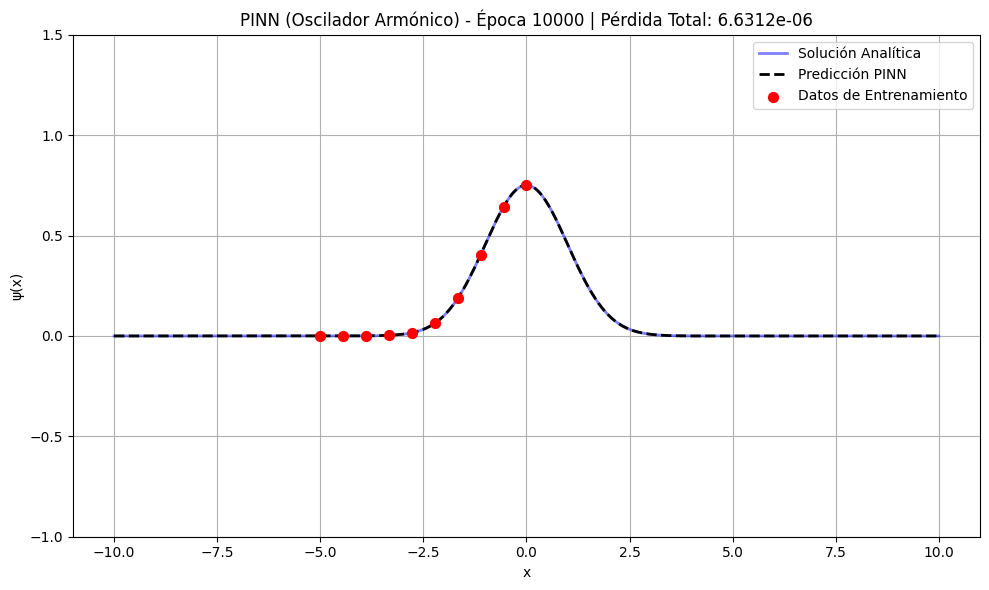

Gráfica guardada con éxito en: ../img/PINN_resultado_estado_n0.png


<Figure size 640x480 with 0 Axes>


--- RESULTADOS FINALES (Estado n=0) ---
Autovalor exacto (varepsilon): 0.5000
Autovalor descubierto por PINN: 0.5000
Error relativo L2 (Función de onda): 7.5186e-04



In [19]:
eps_0, err_0 = train_pinn(n=0, n_epochs=10000, num_train_points=10)

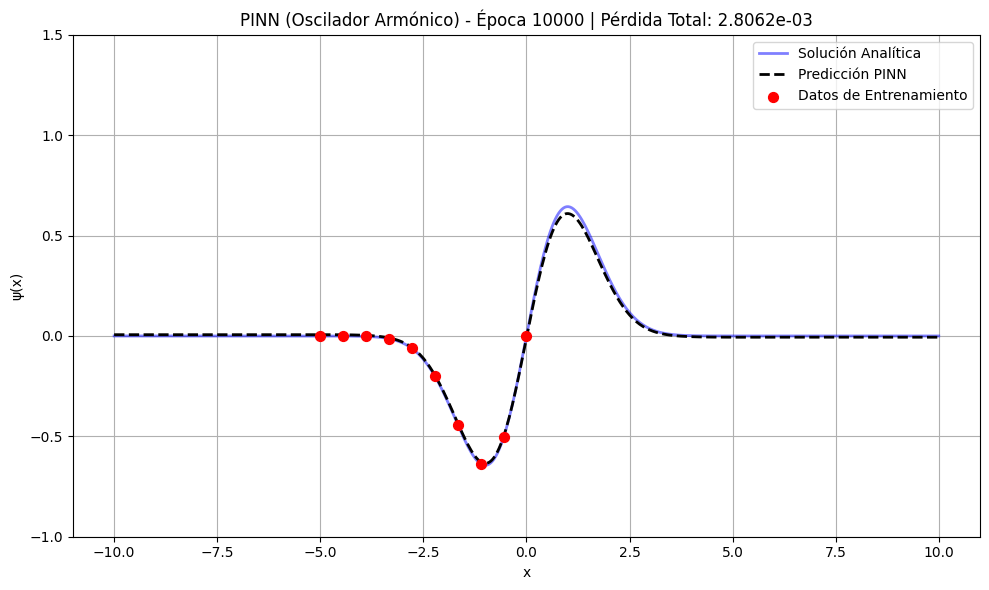

Gráfica guardada con éxito en: ../img/PINN_resultado_estado_n1.png


<Figure size 640x480 with 0 Axes>


--- RESULTADOS FINALES (Estado n=1) ---
Autovalor exacto (varepsilon): 1.5000
Autovalor descubierto por PINN: 1.5139
Error relativo L2 (Función de onda): 4.8410e-02



In [20]:
eps_1, err_1 = train_pinn(n=1, n_epochs=10000, num_train_points=10)

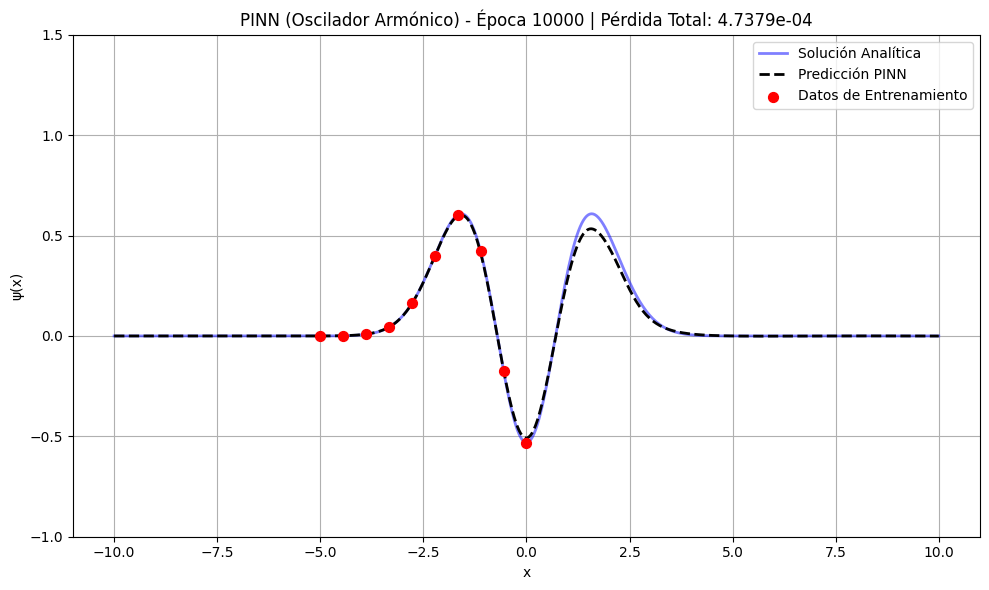

Gráfica guardada con éxito en: ../img/PINN_resultado_estado_n2.png


<Figure size 640x480 with 0 Axes>


--- RESULTADOS FINALES (Estado n=2) ---
Autovalor exacto (varepsilon): 2.5000
Autovalor descubierto por PINN: 2.5001
Error relativo L2 (Función de onda): 7.9910e-02



In [21]:
eps_2, err_2 = train_pinn(n=2, n_epochs=10000, num_train_points=10)

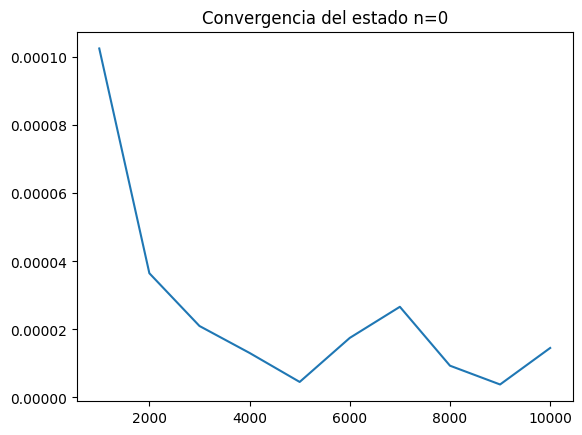

In [6]:
import json

with open("../results/exp_n0_lhs_20260317_171716.json") as f:
    datos = json.load(f)

plt.plot(datos["historial"]["epoch"], datos["historial"]["total_loss"])
plt.title(f"Convergencia del estado n={datos['config']['estado_n']}")
plt.show()

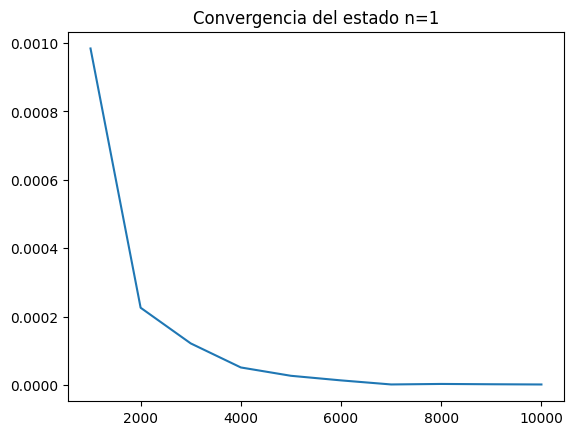

In [7]:
with open("../results/exp_n1_lhs_20260317_182024.json") as f:
    datos = json.load(f)

plt.plot(datos["historial"]["epoch"], datos["historial"]["total_loss"])
plt.title(f"Convergencia del estado n={datos['config']['estado_n']}")
plt.show()

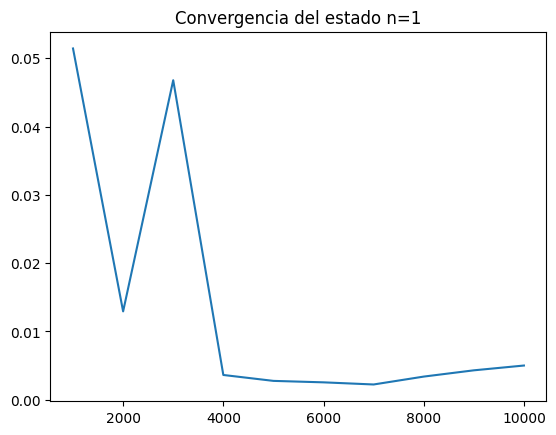

In [8]:
with open("../results/exp_n1_lhs_20260317_181648.json") as f:
    datos = json.load(f)

plt.plot(datos["historial"]["epoch"], datos["historial"]["total_loss"])
plt.title(f"Convergencia del estado n={datos['config']['estado_n']}")
plt.show()

De cara a seguir avanzando, había pensado en los siguientes pasos:
- Empezar a introducir pesos dinámicos en las funciones de pérdida.
- Cambiar la generación de los puntos y usar otros optimizadores.
- No darle puntos y añadir otra restricción que sea que el estado a generar sea ortogonal al estado n = 0.